In [1]:
import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader

from torchvision.models import resnet18

import matplotlib.pyplot as plt

from utils import BaseImageFolderDataset
from utils.transforms import resnet_base_transforms, resnet_train_transforms
from utils.trainer import train

In [2]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.01
LEARNING_RATE = 1e-4
BATCH_SIZE = 16

In [3]:
# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
class VisDA2017Train(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'

class VisDA2017Validation(BaseImageFolderDataset):
    URL = ' http://csr.bu.edu/ftp/visda17/clf/validation.tar'
    ARCHIVE_NAME = 'validation.tar'
    EXTRACTED_FOLDER = 'validation'

In [6]:
train_dataset = VisDA2017Train(
    './data', transform=resnet_train_transforms, download=True
)

val_dataset = VisDA2017Validation(
    './data', transform=resnet_base_transforms, download=True
)

In [7]:
len(train_dataset), len(val_dataset)

(152397, 55388)

In [ ]:
# TODO: Delete after tesing utils

# import numpy as np
# from torch.utils.data import Subset

# np.random.seed(42)

# # Generate random indices for split
# train_indices = np.arange(len(train_dataset))
# val_indices = np.arange(len(val_dataset))

# np.random.shuffle(train_indices)
# np.random.shuffle(val_indices)

# train_size = int(len(train_dataset) * TRAIN_FRACTION)
# val_size = int(len(val_dataset) * TRAIN_FRACTION)

# train_indices = list(train_indices[:train_size])
# val_indices = list(val_indices[:val_size])

# train_dataset = Subset(train_dataset, train_indices)
# val_dataset = Subset(val_dataset, val_indices)

In [9]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

In [10]:
model = resnet18(num_classes=12)

In [11]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [12]:
loss = nn.CrossEntropyLoss()

In [13]:
metrics = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    epochs=4,
    # start_epoch=2,
    checkpoint_interval=2,
    checkpoint_path='.',
    device=GPU
)

Epoch   1 | Train Loss: 2.2748 | Train Acc1: 20.25% | Train Acc5: 67.38% | Val Loss: 3.4684 | Val Acc1: 15.50% | Val Acc5: 50.38%


Epoch   2 | Train Loss: 2.0332 | Train Acc1: 27.37% | Train Acc5: 81.23% | Val Loss: 5.2819 | Val Acc1: 21.27% | Val Acc5: 61.15%
Saving checkpoint...OK


Epoch   3 | Train Loss: 1.8721 | Train Acc1: 30.99% | Train Acc5: 84.90% | Val Loss: 4.1175 | Val Acc1: 19.56% | Val Acc5: 63.73%


Epoch   4 | Train Loss: 1.8083 | Train Acc1: 35.44% | Train Acc5: 83.64% | Val Loss: 5.0918 | Val Acc1: 26.49% | Val Acc5: 61.90%
Saving checkpoint...OK


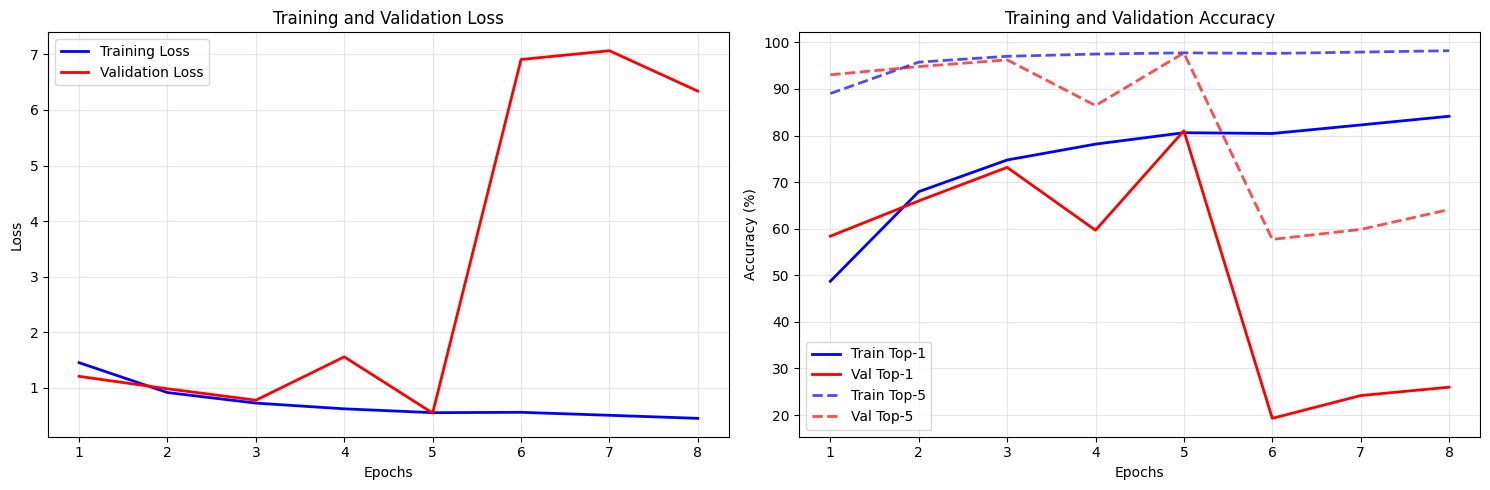

In [4]:
plot_training_metrics(metrics)